<h2 style='color:blue' align='center'>Implementation of mini batch grandient descent in python</h2>

#### We will use very simple home prices data set to implement mini batch gradient descent in python. 

1. Batch gradient descent uses **all** training samples in forward pass to calculate cumulitive error and than we adjust weights using derivaties

2. Stochastic GD: we randomly pick **one** training sample, perform forward pass, compute the error and immidiately adjust weights

3. Mini batch GD: we use a **batch of m samples** where 0 < m < n (where n is total number of training samples)
- Here we will mention no of sample to consider in each iteration as **batch_size**


### Mini GD will use randomly picked batch of training samples to calculate error and using this error we backpropage to adjust weights,


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

##### Load the dataset in pandas dataframe

In [2]:
df = pd.read_csv("homeprices_banglore.csv")
df.sample(5)

,area,bedrooms,price
2,1440,3,62.0
12,1000,2,38.0
7,3300,4,155.0
9,3700,5,167.0
8,1310,3,50.0


In [3]:
df.shape

# as we have less data we take full date for demonstration. In real world we need to split as train, test

(20, 3)

##### Preprocessing/Scaling: Since our columns are on different sacle it is important to perform scaling on them

In [4]:
from sklearn import preprocessing
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_X = sx.fit_transform(df.drop('price',axis='columns'))
scaled_y = sy.fit_transform(df['price'].values.reshape(df.shape[0],1))

scaled_X

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [5]:
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

##### We should convert target column (i.e. price) into one dimensional array. It has become 2D due to scaling that we did above but now we should change to 1D

In [6]:
scaled_y.reshape(20,)

array([0.05237037, 0.65185185, 0.22222222, 0.31851852, 0.14074074,
       0.04444444, 0.76296296, 0.91111111, 0.13333333, 1.        ,
       0.37037037, 0.8       , 0.04444444, 0.05925926, 0.51111111,
       0.07407407, 0.11851852, 0.20740741, 0.51851852, 0.        ])

##### Gradient descent allows you to find weights (w1,w2,w3) and bias in following linear equation for housing price prediction

<img src="hp.jpg"/>

##### Now is the time to implement batch gradient descent. 

<h3 style='color:purple'>(1) Batch Gradient Descent Implementation</h3>

In [8]:
np.random.permutation(20)
# Here it gives 20 random no in diff ordered way

array([ 4,  7,  9,  6, 10, 17, 13, 18, 19,  0,  5,  1,  2,  3, 15, 12, 16,
       11, 14,  8])

In [7]:
#for j in range(0,total_samples,batch_size):
for j in range(0,20,5):
    print(j) # It gives 4 iteration with size or sample rows count=5
    

0
5
10
15


In [8]:
# Use same as Batch Gradient Descent or SGD code, just passing value take random N row instead of all rows or Single row
#Here we will decide mini batch size means no of rows in each batch, based on this we calculate no of batch we need to do full data scan in 1 iteration



def mini_batch_gradient_descent(X, y_true, epochs = 100, batch_size = 5, learning_rate = 0.01):
    
    number_of_features = X.shape[1]
    # numpy array with 1 row and columns equal to number of features. In 
    # our case number_of_features = 3 (area, bedroom and age)
    w = np.ones(shape=(number_of_features)) 
    b = 0
    total_samples = X.shape[0] # number of rows in X
    
    if batch_size > total_samples: # In this case mini batch becomes same as batch gradient descent
        batch_size = total_samples
        
    cost_list = []
    epoch_list = []
    
    #If 20 total records, and batch size 5then it does 20/5=4 batch and each batch with 5 records
    num_batches = int(total_samples/batch_size)
    
    for i in range(epochs):    
        #Here it rearrages all records in dataset
        random_indices = np.random.permutation(total_samples)
        X_tmp = X[random_indices]
        y_tmp = y_true[random_indices]
        
        
        # Here it takes 1st 5 samples and does predict and error calculation and adjusts weight and does same for next 5 records from 6th position to 10
        # Like this it does till End of the data and same iteration continues in next epoch as well
        for j in range(0,total_samples,batch_size):
            Xj = X_tmp[j:j+batch_size]
            yj = y_tmp[j:j+batch_size]
            y_predicted = np.dot(w, Xj.T) + b
            
            w_grad = -(2/len(Xj))*(Xj.T.dot(yj-y_predicted))
            b_grad = -(2/len(Xj))*np.sum(yj-y_predicted)
            
            w = w - learning_rate * w_grad
            b = b - learning_rate * b_grad
                
            cost = np.mean(np.square(yj-y_predicted)) # MSE (Mean Squared Error)
        
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list


In [9]:
w, b, cost, cost_list, epoch_list = mini_batch_gradient_descent(
    scaled_X,
    scaled_y.reshape(scaled_y.shape[0],),
    epochs = 120,
    batch_size = 5
)


w, b, cost

(array([0.71009443, 0.67812893]), -0.23346469783988155, 0.015096895575525807)

###### Check price equation above. In that equation we were trying to find values of w1,w2 and bias. Here we got these values for each of them,
w1 = 0.70998113 

w2 = 0.67805799

bias = -0.23344210245796984

Cost/MSE = 0.015096

###### Now plot epoch vs cost graph to see how cost reduces as number of epoch increases

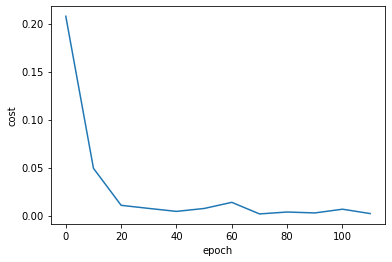

In [10]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

> In Mini GD, Cost vs epoch is not smooth curve, Starting its fluctuating  coz it consideres batch/ or sample of rows and adjust the coefficient, Later it becomes smooth

#### Lets do some predictions now. 

In [11]:
def predict(area,bedrooms,w,b):
    scaled_X = sx.transform([[area, bedrooms]])[0]
    # here w1 = w[0] , w2 = w[1], w3 = w[2] and bias is b
    # equation for price is w1*area + w2*bedrooms + w3*age + bias
    # scaled_X[0] is area
    # scaled_X[1] is bedrooms
    # scaled_X[2] is age
    scaled_price = w[0] * scaled_X[0] + w[1] * scaled_X[1] + b
    # once we get price prediction we need to to rescal it back to original value
    # also since it returns 2D array, to get single value we need to do value[0][0]
    return sy.inverse_transform([[scaled_price]])[0][0]

predict(2600,4,w,b)

128.64383641305122

In [12]:
predict(1000,2,w,b)

29.98034124576567

In [13]:
predict(1500,3,w,b)

69.39525276466189